Série 3 - Quantidade de greves

A série escolhida retrata quantidade de greves por ano durante os anos de 1951 a 1980.
 
Plotando os dados para visualizarmos o comportamente da série:

In [2]:
dados <- read.csv("strikes.csv")

greves <- ts(dados$y,start=c(1951,1))

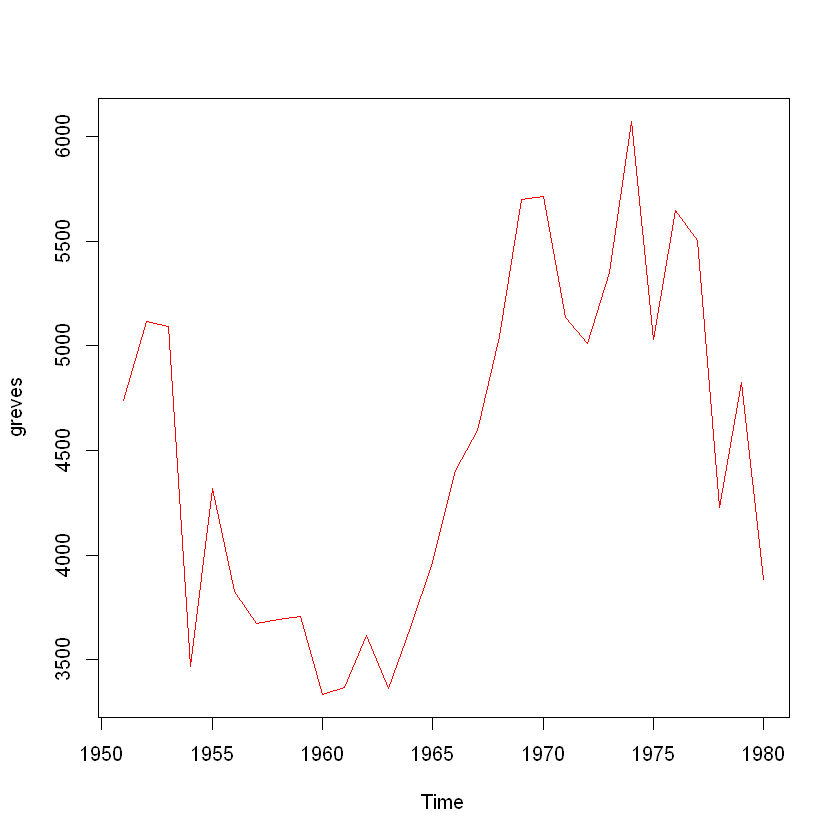

In [3]:
ts.plot(greves,col = "red")

Ao analisar essa série temporal, percebemos que a série não apresenta uma tendência linear simples, e sim apresenta uma tendência não linear, com mudanças de direção ao longo do tempo.

Podemos dizer que a série não tem tendência determinística clara.

---

Fazendo as médias móveis com janela de 3 anos para visualizar a tendência.

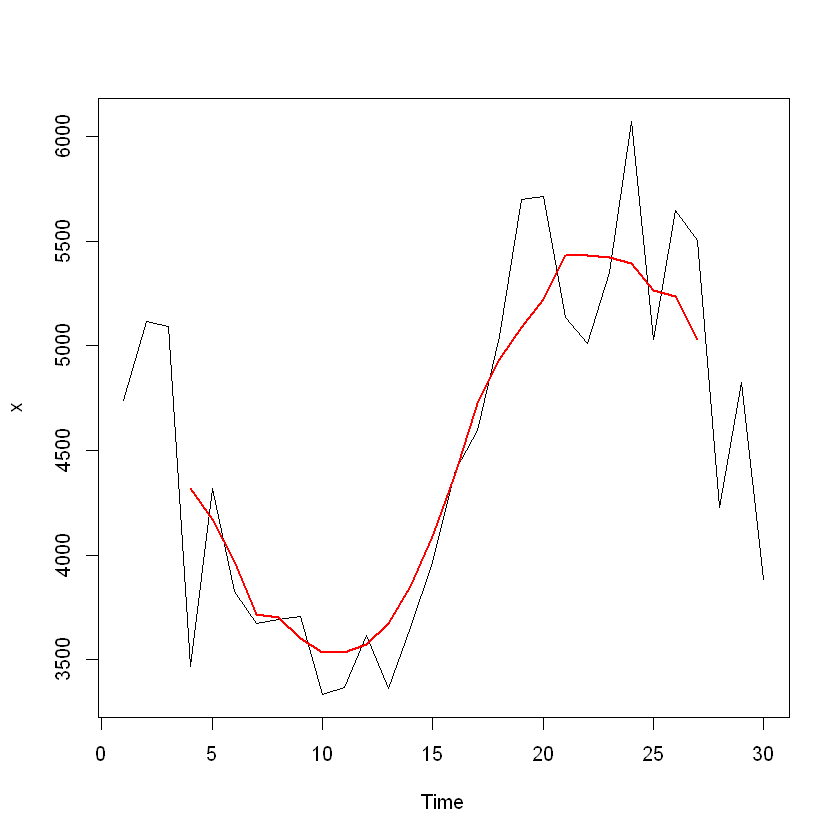

In [4]:
media.moveis(greves,3)


Como visto no gráfico, ao longo do tempo a média a cada 3 anos não segue um tendência linear.

Em relação à sazonalidade, não há indícios visuais claras de sazonalidade (pelo menos no intervalo de tempo observado), o que é consistente com a natureza anual dos dados.

---

Fazendo o gráfico da média e amplitude para determinar $\lambda$ da transformação de Box-Cox


Call:
lm(formula = x.r ~ x.m)

Residuals:
    Min      1Q  Median      3Q     Max 
-550.52 -239.08  -71.15  166.59  948.61 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -401.95288  441.49514  -0.910   0.3710  
x.m            0.25072    0.09672   2.592   0.0154 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 389.5 on 26 degrees of freedom
Multiple R-squared:  0.2054,	Adjusted R-squared:  0.1748 
F-statistic:  6.72 on 1 and 26 DF,  p-value: 0.01544



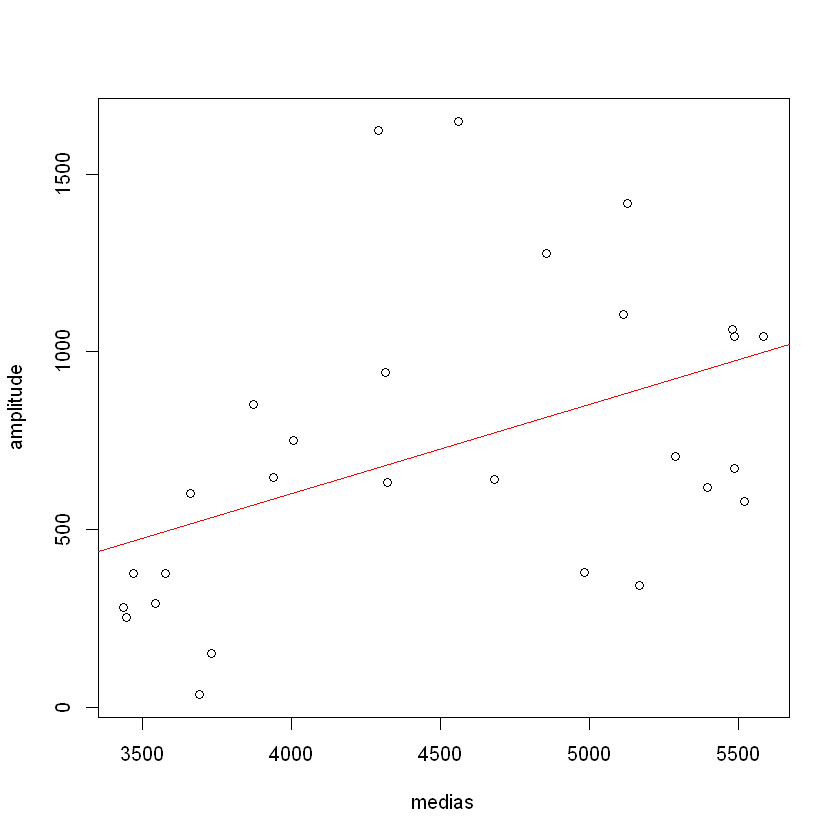

In [5]:
media.amplitude(greves,2)

Fazendo transformação de Box-Cox para estabilizar a variação. ($\lambda= 0.25$)

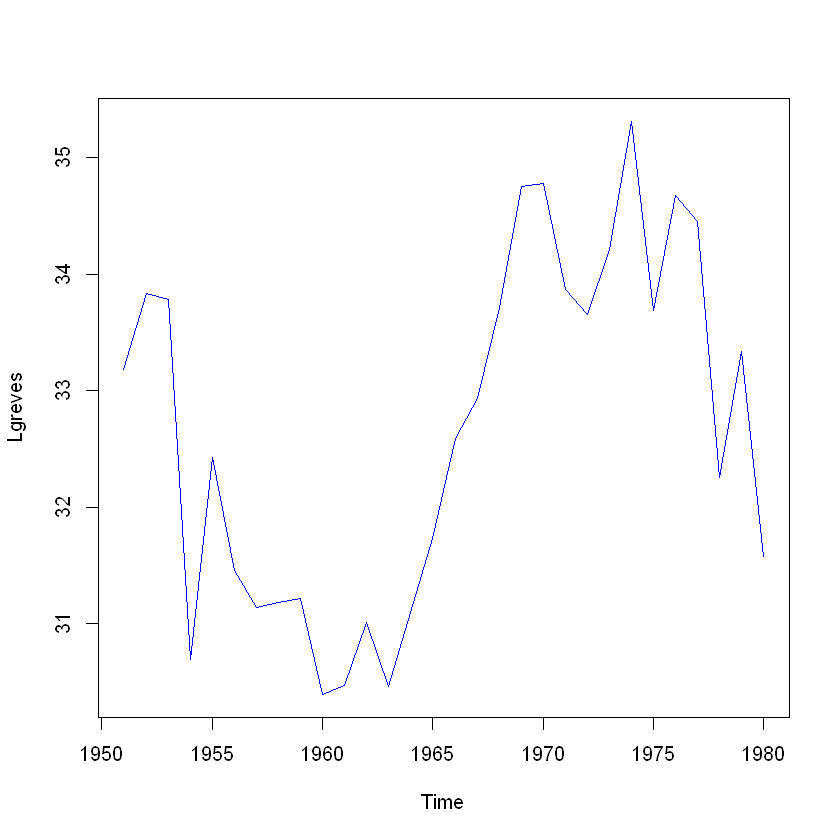

In [7]:
Lgreves <- greves^0.25 /0.25
ts.plot(Lgreves,col = "blue")

Note que a transformação de Box-Cox não modificou o comportamento da série. 

---

Fazendo gráfico da diferença ao longo da série:

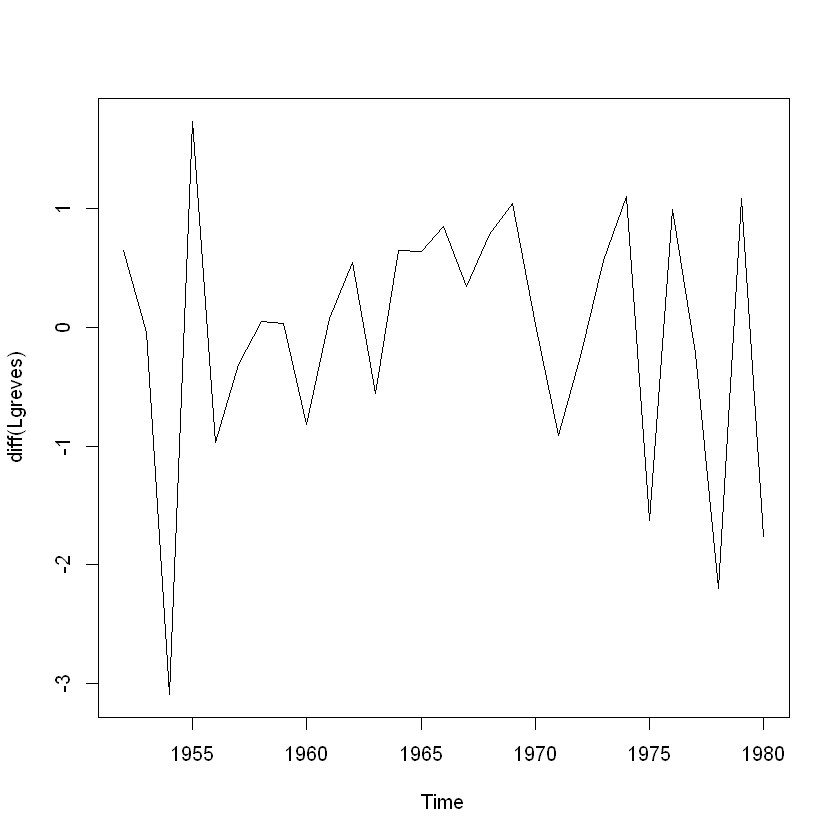

In [9]:
plot(diff(Lgreves))

Olhando o gráfico da diferença podemos dizer que a variabilidade não é constante, já que parece que a média da diferença não está em torno de 0, ou seja há indícios visuais de variação na dispersão.

---

Por fim temos indícios visuais de que a série não tem tendência linear, é heterocedástica, e não sazonal.

---

In [8]:
media.amplitude<-function(x,k)
{N<-length(x)
x.m<-rep(0,(N-k))
x.r<-rep(0,(N-k))
for (i in 1:(N-k)) x.m[i]<-mean(x[i:(i+k)])
for (i in 1:(N-k)) x.r[i]<-max(x[i:(i+k)])-min(x[i:(i+k)])
plot(x.m,x.r,xlab="medias",ylab="amplitude")
aa1<-lm(x.r~x.m)
print(summary(aa1))
abline(aa1$coef[1],aa1$coef[2],col=2)
}
media.moveis<-function(x,k)
{x<-as.vector(x)
N<-length(x)
xstar<-rep(0,N)
for (i in 1:k) xstar[i]<-NA
for (i in (1+k):(N-k)) xstar[i]<-mean(x[(i-k):(i+k)],na.rm=TRUE)
for (i in (N-k+1):N) xstar[i]<-NA
ts.plot(x)
lines(xstar, col=2, lwd=2)}

mediana.bloco<-function(x,k)
{x<-as.vector(x)
N<-length(x)
xstar<-rep(0,N)
for (i in 1:k) xstar[i]<-NA
for (i in (1+k):(N-k)) xstar[i]<-median(x[(i-k):(i+k)],na.rm=TRUE)
for (i in (N-k+1):N) xstar[i]<-NA
ts.plot(x)
lines(xstar, col=2, lwd=2)
}
grafico.sazonalidade<-function(x,s){
  x<-as.vector(x)
  N<-length(x)
  Mx<-max(x)
  mx<-min(x)
  valor<-N%/%s
  eixox<-seq(1:s)
  plot(eixox,x[1:s],ylim=c(mx,Mx),xlim=c(0,(s+1)),type="l")
  for (i in 1:valor){
    y<-rep(NA,s)
    y[1:s]<-x[((i-1)*s+1):(i*s)]
     lines(y,col=i)
  }
  y<-rep(NA,s)
  y<-x[(valor*s+1):N]
  lines(y,col=(valor+1))
}